# Lab 1-2 - Środowisko Programistyczne + Wprowadzenie do uczenia maszynowego

## Konfiguracja środowiska programistycznego
### Google Colab: https://colab.research.google.com/github/yy/dviz-course/blob/master/docs/m01-intro/lab01.ipynb
### Pycharm: https://www.jetbrains.com/help/pycharm/creating-virtual-environment.html

## Przydatne linki

### Integracja Colab-GitHub: https://colab.research.google.com/github/googlecolab/colabtools/blob/master/notebooks/colab-github-demo.ipynb

### Synchronizacja Pycharm-Github: https://www.jetbrains.com/help/pycharm/github.html

### Podstawy operacji na ramkach danych w Pandas: https://www.kaggle.com/learn/pandas

### Tworzenie wykresów w seaborn: https://www.kaggle.com/code/vijayjoshi17/seaborn-guide-all-important-plots

# Zadania:



## Ocena zadań
### Zasady oceniania dla listy 1:
Student w ciągu 5-6 minut prezentuje i omawia napisany przez siebie kod, a następnie prowadzący zadaje 1-2 pytania do całości listy w celu werfikacji czy student rozumie kod, który zaprezentował.

Za każde zadanie można dostać maksymalnie 2 punkty.

### Ocena jest redukowana o 1 punkt w przypadku:
- niepełnej realizacji polecenia (np. brak jednego z podpunktów)
- niezdolności do odpowiedzi na pytanie ze zrozumienia kodu
- popełnienia błędu w kodzie

## Wykorzystywane zbiory danych
Poniższa lista zadań wykorzystuje dwa zbiory danych dostępne na platformie Kaggle:

### Dla zadań 1-4:

Student Lifestyle and Academic Performance Dataset: https://www.kaggle.com/datasets/sehaj1104/student-lifestyle-and-academic-performance-dataset

### Dla zadania nr 5:

Social Media Viral Content and Engagement Metrics: https://www.kaggle.com/datasets/aliiihussain/social-media-viral-content-and-engagement-metrics

## Dokumentacje bibliotek potrzebnych do realizacji zadań:
- pandas: https://pandas.pydata.org/docs/index.html
- seaborn: https://seaborn.pydata.org/
- matplotlib: https://matplotlib.org/stable/


In [10]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [2]:
import kagglehub
import os

students_path = kagglehub.dataset_download("sehaj1104/student-lifestyle-and-academic-performance-dataset")
social_media_path = kagglehub.dataset_download("aliiihussain/social-media-viral-content-and-engagement-metrics")
print(os.listdir(students_path))
print(os.listdir(social_media_path))

Using Colab cache for faster access to the 'student-lifestyle-and-academic-performance-dataset' dataset.
Using Colab cache for faster access to the 'social-media-viral-content-and-engagement-metrics' dataset.
['student_lifestyle_performance_dataset.csv']
['social_media_viral_content_dataset.csv']


## Zadanie 1
Wyświetl ramkę danych spełniającą następujące kryteria:
- ramka zawiera wyłącznie informacje o wieku studentów oraz tym jak spędzają czas.
- ramka zawiera informacje wyłącznie o 15 studentach z najwyższą średnią (CGPA)
- ramka jest posortowana pod względem średniej, tak by student z najwyższą średnią był wyświetlany jako pierwszy

In [3]:
df = pd.read_csv(os.path.join(students_path, "student_lifestyle_performance_dataset.csv"))
df.sort_values(by="CGPA", ascending=False).head(15).sort_values(by="Internal_Marks", ascending=False)[["Age", "Study_Hours_per_Day", "Sleep_Hours", "Screen_Time_Hours", "Gym_Hours_per_Week"]]

,Age,Study_Hours_per_Day,Sleep_Hours,Screen_Time_Hours,Gym_Hours_per_Week
659,20,3.85,9.22,7.14,5.21
109,23,5.83,9.26,7.19,6.05
405,17,6.87,7.92,2.21,18.13
639,19,7.30,8.57,3.96,8.24
156,24,5.41,7.66,5.62,0.21
475,19,5.71,8.07,2.98,12.96
682,25,4.87,8.25,4.95,0.00
464,25,5.18,9.13,7.92,7.85
171,20,8.05,7.34,6.46,0.00
768,24,8.01,6.77,7.07,1.80


## Zadanie 2
dodaj do ramki danych kolumnę z wyliczoną średnią ilością czasu wolnego, którym student dysponuje w ciągu dnia.


### Wyliczając wartość czasu wolnego przyjmij następujące założenia:
- czas wolny studenta to cały czas, którego **NIE** poświęca na naukę, ćwiczenia, sen oraz siedzenie przed ekranem oraz na jedzenie i czynności higieniczne
- około godzina czasu spędzonego przed ekranem to czas poświęcony na naukę
- jedzenie i czynności higieniczne zajmują przeciętnej osobie 2,5 godziny w ciągu dnia

### Następnie wyświetl otrzymaną ramkę danych tak, by spełniała następujące kryteria:
- wyświetl wyłącznie dodatkową kolumnę oraz kolumny wykorzystane do wyliczenia ilości czasu wolnego
- kolumna z czasem wolnym powinna wyświetlać się jako pierwsza z lewej
- czas wolny powinien być zaokrąglony do drugiej liczby po przecinku

In [16]:
df["Study_Hours_per_Day_On_Screen"] = np.where(df["Screen_Time_Hours"] >= 1.0, 1, 0)

df["Free_Time"] = 24-df["Study_Hours_per_Day"]-df["Sleep_Hours"]-df["Study_Hours_per_Day_On_Screen"]-(2.5)-round(df["Gym_Hours_per_Week"]/7, 2)
df[["Free_Time", "Study_Hours_per_Day_On_Screen"]].sort_values(by="Free_Time", ascending=False)

,Free_Time,Study_Hours_per_Day_On_Screen
361,15.69,1
595,15.09,1
216,15.08,1
265,14.84,1
135,14.77,1
...,...,...
657,3.39,1
49,3.16,1
405,3.12,1
12,3.04,1


## Zadanie 3
utwórz ramkę danych pozwalającą odpowiedzieć na następujące pytania
- Jaka dziedzina naukowa (*Branch*) jest najbardziej stresująca?
- Czy mediana snu wśród studentów informatyki (*IT*) jest wyższa niż wśród studentów mechaniki (*Mechanical*)?
### UWAGA!
Uwzględnij wyłącznie informacje o pełnoletnich studentach.

In [23]:
df[df["Age"]>=18].groupby("Branch").agg(
    stress=("Stress_Level_1_to_10", "mean"),
    sleep=("Sleep_Hours", "median")
).sort_values(by="stress", ascending=False)

,stress,sleep
Branch,,
Civil,4.630494,6.710
ECE,4.626014,6.405
Mechanical,4.608940,6.640
Electrical,4.544621,6.310
CSE,4.526667,6.540
IT,4.454929,6.755


## Zadanie 4
Przedstaw na wykresach:
- zależność między czasem snu a osiąganą średnią z uwzględnieniem diety studenta
- średnią obecność na zajęciach dla poszczególnych dziedzin naukowych
### UWAGA!
potraktuj informatykę (*IT*) i inżynierię komputerową (*CSE*) jako jedną dziedzinę

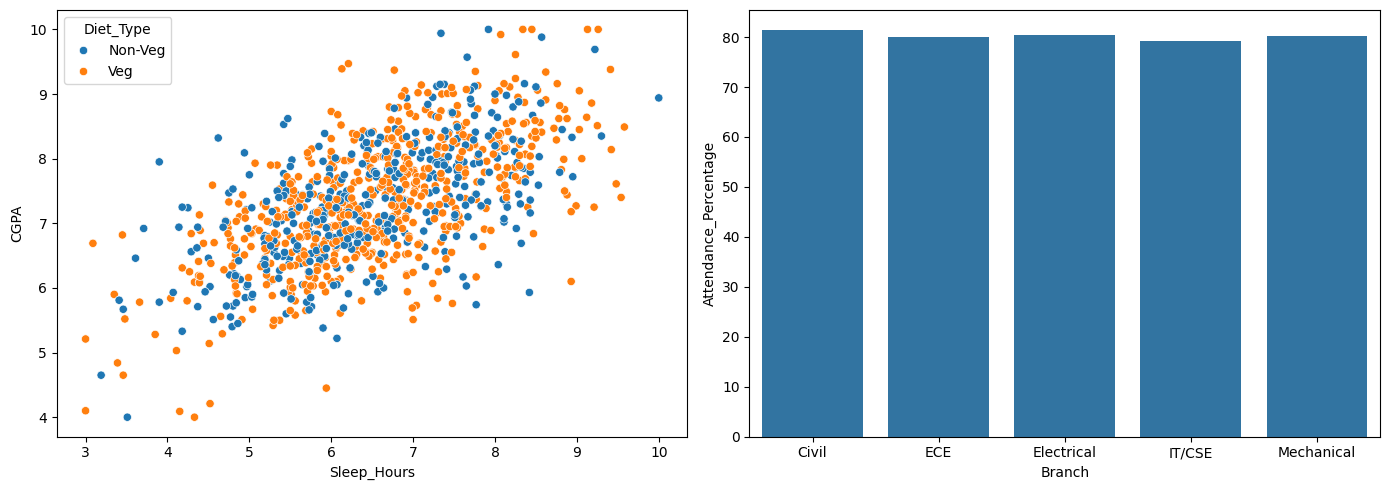

In [27]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(data=df, x="Sleep_Hours", y="CGPA", hue="Diet_Type", ax=ax1)

df_plot = df.copy()
df_plot["Branch"] = df_plot["Branch"].replace({"IT": "IT/CSE", "CSE": "IT/CSE"})
attendance = df_plot.groupby("Branch")["Attendance_Percentage"].mean().reset_index()
sns.barplot(data=attendance, x="Branch", y="Attendance_Percentage", ax=ax2)

plt.tight_layout()
plt.show()

## Zadanie 5:
Utwórz wykresy, które pozwalają przedstawić następujące informacje:
- Najpopularniejsze tematy filmów na YouTube Shorts w ostatnim kwartale 2024 roku
- Jaki hasztag najbardziej opłaca się umieszczać w  postach na poszczególnych platformach?